In [35]:
import pymc
import pymc as pm, arviz as az, numpy as np

from utils import extract_quantile_columns, standardize_columns, plot_trace

In [40]:
with pymc.Model() as model:
    alpha = pm.Normal("alpha", 0, 1.5)
    prob = pm.Deterministic("probability_of_rain", pm.invlogit(alpha))

    successes = pm.Binomial("rain_occurrences", n=[4], p=prob, observed=[3])

    # sample priors
    prior_predictive = pm.sample_prior_predictive()

    # sample
    posterior = pm.sample(chains=4, draws=5000)
    posterior_predictive = pm.sample_posterior_predictive(posterior)
    pm.compute_log_likelihood(posterior)

Sampling: [alpha, rain_occurrences]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha]


Output()

Sampling 4 chains for 1_000 tune and 5_000 draw iterations (4_000 + 20_000 draws total) took 1 seconds.
Sampling: [rain_occurrences]


Output()

Output()

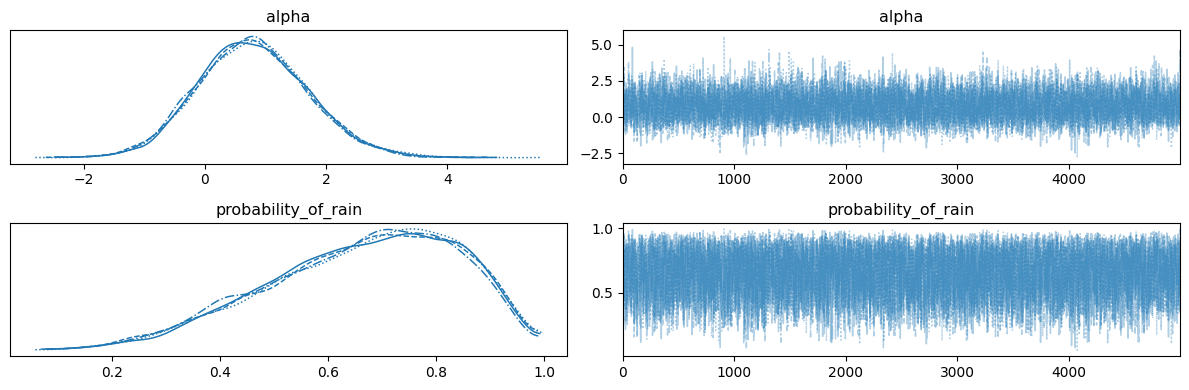

In [41]:
plot_trace(posterior)

In [45]:
observed = [1,0,1,1]

with pymc.Model() as bernouli_model:
    alpha = pm.Normal("alpha", pm.logit(0.5), 1.5)
    prob = pm.Deterministic("probability_of_rain", pm.invlogit(alpha))

    successes = pm.Bernoulli("rain_occurrence", prob, observed=observed)

    # sample priors
    bernoulli_prior_predictive = pm.sample_prior_predictive(var_names=["alpha", "probability_of_rain"])

    # sample
    bernoulli_posterior = pm.sample(chains=4, draws=5000)
    posterior_predictive = pm.sample_posterior_predictive(bernoulli_posterior)
    pm.compute_log_likelihood(bernoulli_posterior)

Sampling: [alpha]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha]


Output()

Sampling 4 chains for 1_000 tune and 5_000 draw iterations (4_000 + 20_000 draws total) took 1 seconds.
Sampling: [rain_occurrence]


Output()

Output()

<Axes: >

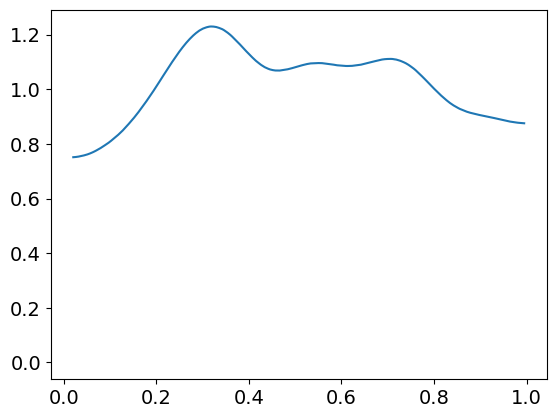

In [46]:
az.plot_dist(bernoulli_prior_predictive.prior["probability_of_rain"].values.flatten())

<Axes: >

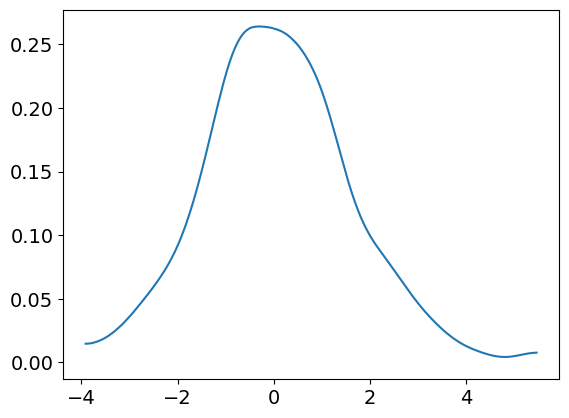

In [47]:
az.plot_dist(bernoulli_prior_predictive.prior["alpha"].values.flatten())

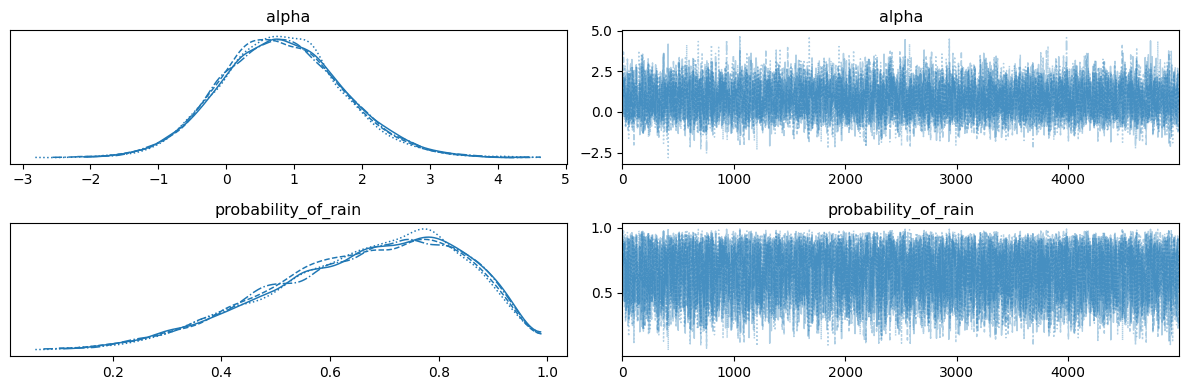

In [48]:
plot_trace(bernoulli_posterior)

In [ ]:
observed = [1] * 10

with pymc.Model() as discrete_model:
    # Choose between two options: 0 = 75%, 1 = 90%
    choice = pm.Categorical("choice", p=[0.5, 0.5])
    
    # Map choice to probability values
    prob_values = pm.math.stack([0.75, 0.90])
    prob = pm.Deterministic("probability_of_rain", prob_values[choice])
    
    # Calculate corresponding alpha (logit of probability)
    alpha = pm.Deterministic("alpha", pm.logit(prob))
    
    # Bernoulli likelihood
    successes = pm.Bernoulli("rain_occurrence", prob, observed=observed)
    
    # Sample prior
    discrete_prior_predictive = pm.sample_prior_predictive(var_names=["choice", "alpha", "probability_of_rain"])
    
    # Sample posterior
    discrete_posterior = pm.sample(chains=4, draws=5000)
    discrete_posterior_predictive = pm.sample_posterior_predictive(discrete_posterior)
    pm.compute_log_likelihood(discrete_posterior)

Sampling: [choice]
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [choice]


Output()

Sampling 4 chains for 1_000 tune and 5_000 draw iterations (4_000 + 20_000 draws total) took 1 seconds.
Sampling: [rain_occurrence]


Output()

Output()

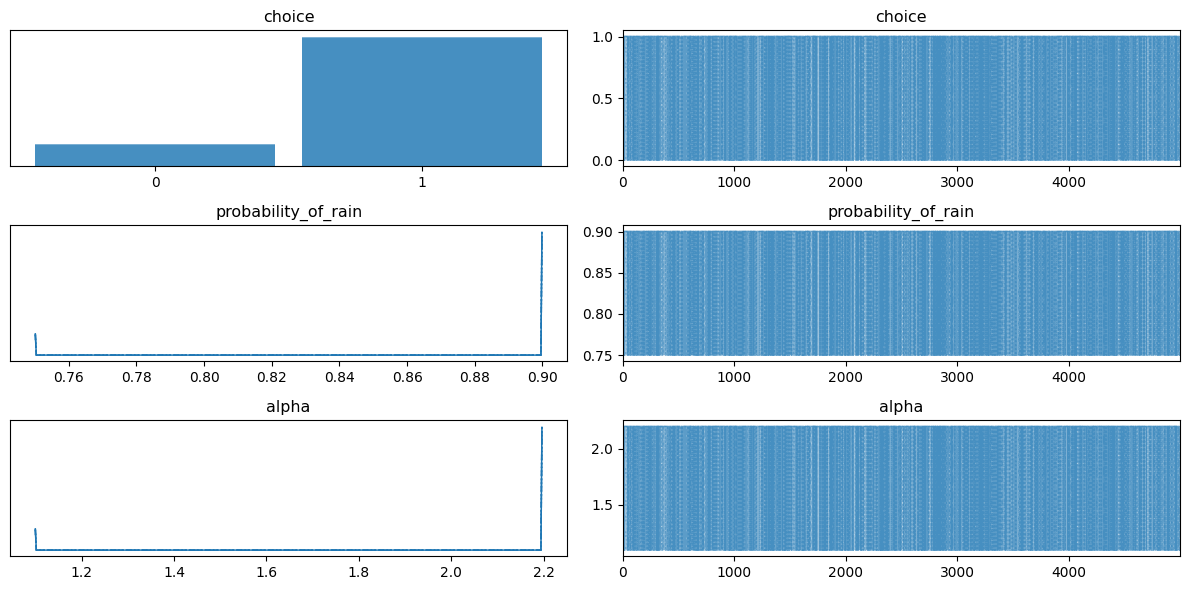

In [58]:
plot_trace(discrete_posterior)